Dataset Info:
Total samples: 1572
Speakers: 9

Speaker distribution:
speaker_id
Speaker_id_4    329
Speaker_id_3    327
Speaker_id_1    268
Speaker_id_6    200
Speaker_id_2    172
Speaker_id_7    146
Speaker_id_5    120
speaker_001       5
speaker_002       5
Name: count, dtype: int64


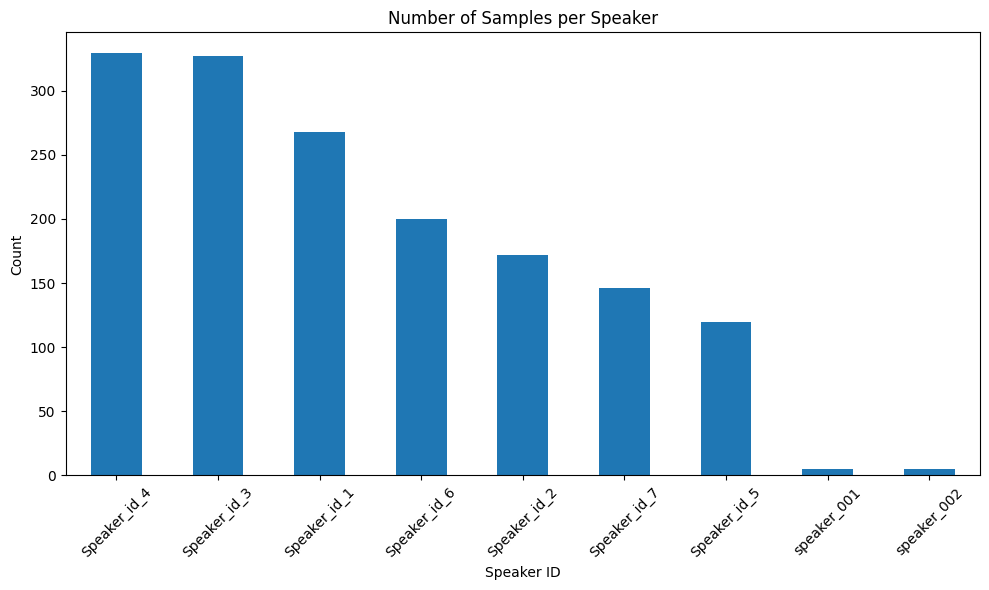

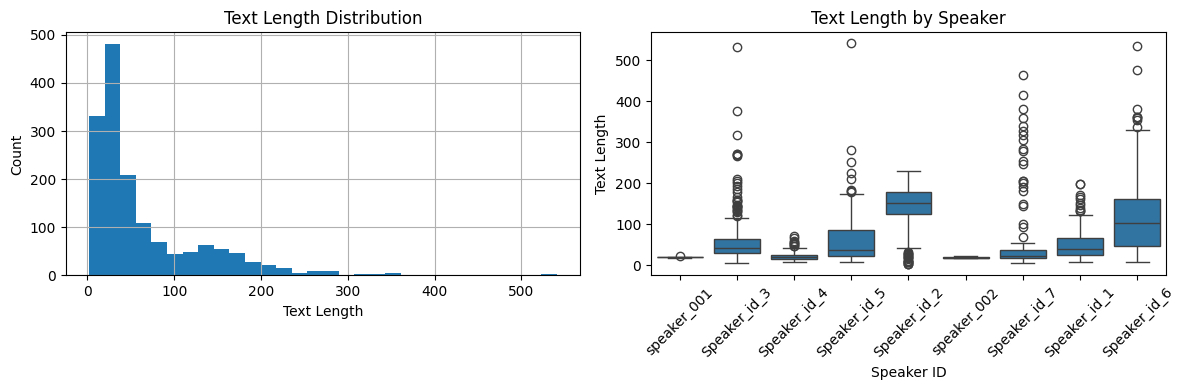

In [11]:
# This is a Jupyter notebook for data exploration and visualization
# Create a new Jupyter notebook with this content

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import librosa
import librosa.display
import numpy as np
from IPython.display import Audio
import warnings
warnings.filterwarnings('ignore')

# Load metadata
metadata = pd.read_csv("../data/processed/metadata.csv")

# Display basic info
print("Dataset Info:")
print(f"Total samples: {len(metadata)}")
print(f"Speakers: {metadata['speaker_id'].nunique()}")
print("\nSpeaker distribution:")
print(metadata['speaker_id'].value_counts())

# Plot speaker distribution
plt.figure(figsize=(10, 6))
metadata['speaker_id'].value_counts().plot(kind='bar')
plt.title('Number of Samples per Speaker')
plt.xlabel('Speaker ID')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Text length analysis
metadata['text_length'] = metadata['text'].str.len()

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
metadata['text_length'].hist(bins=30)
plt.title('Text Length Distribution')
plt.xlabel('Text Length')
plt.ylabel('Count')

plt.subplot(1, 2, 2)
sns.boxplot(x='speaker_id', y='text_length', data=metadata)
plt.title('Text Length by Speaker')
plt.xlabel('Speaker ID')
plt.ylabel('Text Length')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


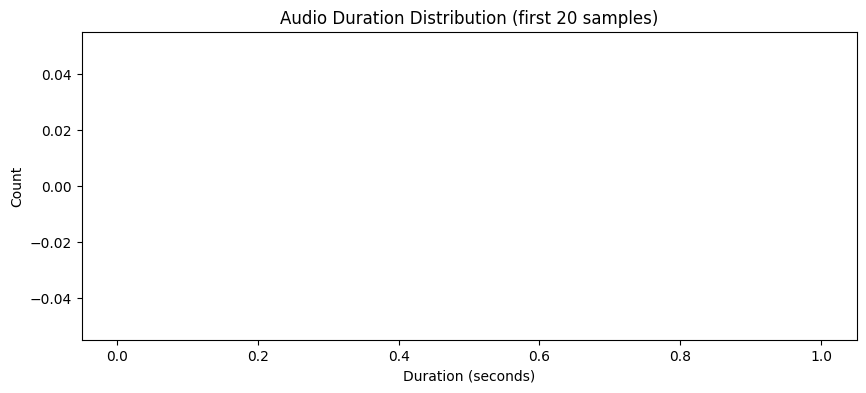


Audio duration statistics:


ValueError: zero-size array to reduction operation minimum which has no identity

In [17]:
# Audio analysis
from pathlib import Path

def plot_audio_features(audio_path, text):
    """Plot audio features for a sample"""
    audio_path = Path(audio_path)
    if not audio_path.exists():
        alt_path = Path("..") / audio_path
        if alt_path.exists():
            audio_path = alt_path
        else:
            warnings.warn(f"Missing audio file: {audio_path}")
            return None

    audio, sr = librosa.load(audio_path, sr=22050)
    
    fig, axes = plt.subplots(3, 1, figsize=(12, 8))
    
    # Waveform
    axes[0].plot(audio)
    axes[0].set_title(f'Waveform: "{text[:50]}..."')
    axes[0].set_xlabel('Sample')
    axes[0].set_ylabel('Amplitude')
    
    # Spectrogram
    D = librosa.amplitude_to_db(np.abs(librosa.stft(audio)), ref=np.max)
    img = librosa.display.specshow(D, y_axis='log', x_axis='time', sr=sr, ax=axes[1])
    axes[1].set_title('Spectrogram')
    plt.colorbar(img, ax=axes[1], format='%+2.0f dB')
    
    # Mel-spectrogram
    mel = librosa.feature.melspectrogram(y=audio, sr=sr)
    mel_db = librosa.amplitude_to_db(mel, ref=np.max)
    img2 = librosa.display.specshow(mel_db, y_axis='mel', x_axis='time', sr=sr, ax=axes[2])
    axes[2].set_title('Mel-Spectrogram')
    plt.colorbar(img2, ax=axes[2], format='%+2.0f dB')
    
    plt.tight_layout()
    plt.show()
    
    audio_player = plot_audio_features(row['audio_path'], row['text'])
    if audio_player is not None:
        display(audio_player)

# Analyze a few samples
for audio_path in metadata['audio_path'].head(20):  # Limit to 20 for speed
    try:
        audio_path = Path(audio_path)
        if not audio_path.exists():
            alt_path = Path("..") / audio_path
            if alt_path.exists():
                audio_path = alt_path
            else:
                continue

        audio, sr = librosa.load(audio_path, sr=None)
        duration = len(audio) / sr
        durations.append(duration)
    except:
        continue
    audio_player = plot_audio_features(row['audio_path'], row['text'])
    display(audio_player)

# Duration analysis
durations = []
for audio_path in metadata['audio_path'].head(20):  # Limit to 20 for speed
    try:
        audio, sr = librosa.load(audio_path, sr=None)
        duration = len(audio) / sr
        durations.append(duration)
    except:
        continue

plt.figure(figsize=(10, 4))
plt.hist(durations, bins=20)
plt.title('Audio Duration Distribution (first 20 samples)')
plt.xlabel('Duration (seconds)')
plt.ylabel('Count')
plt.show()

print(f"\nAudio duration statistics:")
print(f"Min: {np.min(durations):.2f}s")
print(f"Max: {np.max(durations):.2f}s")
print(f"Mean: {np.mean(durations):.2f}s")
print(f"Std: {np.std(durations):.2f}s")

In [1]:
import torch

In [2]:
print(f'CUDA available: {torch.cuda.is_available()}'); print(f'CUDA devices: {torch.cuda.device_count()}')

CUDA available: True
CUDA devices: 1


In [ ]:
nvidia-smi

NameError: name 'nvidia' is not defined

: 